# 基于用户档案模式的聊天机器人

## 回顾

我们介绍了 [LangGraph 内存存储](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) 作为保存和检索长期记忆的一种方式。

我们构建了一个简单的聊天机器人，它同时使用 `短期记忆（线程内）` 和 `长期记忆（跨线程）`。

它保存了长期 [语义记忆](https://langchain-ai.github.io/langgraph/concepts/memory/#semantic-memory)（关于用户的事实信息）["在热路径中"](https://langchain-ai.github.io/langgraph/concepts/memory/#writing-memories)，即用户与机器人聊天时。

## 目标

我们的聊天机器人将记忆保存为字符串。在实践中，我们通常希望记忆具有结构。

例如，记忆可以是一个 [单一的、持续更新的模式](https://langchain-ai.github.io/langgraph/concepts/memory/#profile)。

在我们的案例中，我们希望这是一个单一的用户档案。

我们将扩展我们的聊天机器人，将语义记忆保存到单个 [用户档案](https://langchain-ai.github.io/langgraph/concepts/memory/#profile) 中。

我们还将介绍一个库 [Trustcall](https://github.com/hinthornw/trustcall)，用于使用新信息更新这个模式。

## 技术背景

**什么是结构化记忆？**
- 传统上，聊天机器人的记忆是简单的文本字符串
- 结构化记忆使用预定义的数据模式（Schema）来组织信息
- 这使得记忆更加可预测、可查询和可维护

**为什么需要用户档案模式？**
- 提供一致的用户信息存储格式
- 便于在不同会话间保持用户偏好
- 支持更智能的个性化响应 

In [ ]:
# 安装必要的依赖包
# 这些包是构建基于用户档案的聊天机器人所必需的
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

In [ ]:
import os, getpass

def _set_env(var: str):
    """
    设置环境变量的辅助函数
    
    参数:
        var (str): 环境变量名称
    """
    # 检查环境变量是否已在操作系统中设置
    env_value = os.environ.get(var)
    if not env_value:
        # 如果未设置，提示用户输入
        env_value = getpass.getpass(f"{var}: ")
    
    # 为当前进程设置环境变量
    os.environ[var] = env_value

# 设置 LangSmith API 密钥用于追踪和监控
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"  # 启用追踪功能
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"  # 设置项目名称

## 定义用户档案模式

Python 有多种不同的 [结构化数据](https://python.langchain.com/docs/concepts/structured_outputs/#schema-definition) 类型，如 TypedDict、字典、JSON 和 [Pydantic](https://docs.pydantic.dev/latest/)。

让我们从使用 TypedDict 定义用户档案模式开始。

### 什么是模式（Schema）？
- **模式** 是数据的结构定义，类似于数据库表结构
- 它定义了数据应该包含哪些字段以及每个字段的类型
- 在聊天机器人中，模式帮助我们以一致的方式存储和检索用户信息

### TypedDict vs Pydantic
- **TypedDict**: Python 内置，轻量级，主要用于类型提示
- **Pydantic**: 功能更强大，支持数据验证、序列化等高级功能

In [ ]:
from typing import TypedDict, List

class UserProfile(TypedDict):
    """
    用户档案模式，包含类型化的字段
    
    这个类定义了用户档案的基本结构，包含用户名和兴趣列表
    使用 TypedDict 确保类型安全，同时保持字典的灵活性
    """
    user_name: str  # 用户的首选名称
    interests: List[str]  # 用户兴趣列表

## 将模式保存到存储中

[LangGraph 存储](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) 接受任何 Python 字典作为 `value`。

### 存储系统的工作原理
- **命名空间（Namespace）**: 用于组织和隔离不同用户的数据
- **键（Key）**: 在命名空间内唯一标识特定数据的标识符
- **值（Value）**: 实际存储的数据，可以是任何 Python 对象 

In [ ]:
# 创建 TypedDict 实例
# 这里我们创建一个具体的用户档案示例
user_profile: UserProfile = {
    "user_name": "Lance",
    "interests": ["biking", "technology", "coffee"]
}
user_profile

{'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}

我们使用 [put](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore.put) 方法将 TypedDict 保存到存储中。

### put 方法详解
- **功能**: 将数据存储到指定的命名空间和键下
- **参数**: 
  - `namespace`: 命名空间元组，用于组织数据
  - `key`: 数据键，在命名空间内唯一
  - `value`: 要存储的数据对象

In [ ]:
import uuid
from langgraph.store.memory import InMemoryStore

# 初始化内存存储
# InMemoryStore 是一个简单的内存存储实现，适合演示和开发
in_memory_store = InMemoryStore()

# 为要保存的记忆设置命名空间
# 命名空间格式: (用户ID, 记忆类型)
user_id = "1"
namespace_for_memory = (user_id, "memory")

# 将记忆保存到命名空间，使用键值对存储
key = "user_profile"  # 在命名空间内的唯一标识符
value = user_profile  # 要存储的用户档案数据
in_memory_store.put(namespace_for_memory, key, value)

我们使用 [search](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore.search) 方法通过命名空间从存储中检索对象。

### search 方法详解
- **功能**: 搜索指定命名空间下的所有对象
- **返回**: 包含匹配对象的迭代器
- **用途**: 查看命名空间内存储的所有数据

In [ ]:
# 搜索并显示存储的数据
# 遍历命名空间中的所有对象并打印其详细信息
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'value': {'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}, 'key': 'user_profile', 'namespace': ['1', 'memory'], 'created_at': '2024-11-04T23:37:34.871675+00:00', 'updated_at': '2024-11-04T23:37:34.871680+00:00'}


我们也可以使用 [get](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore.get) 方法通过命名空间和键检索特定对象。

### get 方法详解
- **功能**: 根据命名空间和键精确检索单个对象
- **参数**:
  - `namespace`: 命名空间元组
  - `key`: 对象键
- **返回**: 包含对象数据的存储项
- **用途**: 快速获取特定的用户档案数据

In [ ]:
# 通过命名空间和键获取记忆
# 精确检索特定的用户档案数据
profile = in_memory_store.get(namespace_for_memory, "user_profile")
profile.value  # 获取存储项的值部分

{'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}

## 基于档案模式的聊天机器人

现在我们知道如何为记忆指定模式并将其保存到存储中。

但是，我们如何实际使用这个特定模式*创建*记忆呢？

在我们的聊天机器人中，我们 [希望从用户聊天中创建记忆](https://langchain-ai.github.io/langgraph/concepts/memory/#profile)。

这就是 [结构化输出](https://python.langchain.com/docs/concepts/structured_outputs/#recommended-usage) 概念发挥作用的地方。

LangChain 的 [聊天模型](https://python.langchain.com/docs/concepts/chat_models/) 接口有一个 [`with_structured_output`](https://python.langchain.com/docs/concepts/structured_outputs/#recommended-usage) 方法来强制结构化输出。

当我们希望确保输出符合模式并为我们解析输出时，这非常有用。

### 什么是结构化输出？
- **定义**: 确保 AI 模型输出符合预定义格式的技术
- **优势**: 
  - 保证数据格式一致性
  - 便于后续处理和存储
  - 减少解析错误
- **实现**: 通过 `with_structured_output` 方法将模式绑定到模型

In [ ]:
# 设置 OpenAI API 密钥
# 这是使用 OpenAI 模型所必需的
_set_env("OPENAI_API_KEY")

让我们将创建的 `UserProfile` 模式传递给 `with_structured_output` 方法。

然后我们可以使用 [消息](https://python.langchain.com/docs/concepts/messages/) 列表调用聊天模型，并获得符合我们模式的结构化输出。

### 工作流程
1. **模式绑定**: 将用户档案模式绑定到聊天模型
2. **消息输入**: 提供用户对话消息
3. **结构化输出**: 模型返回符合模式的用户档案数据
4. **数据验证**: 自动确保输出格式正确

In [ ]:
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

# 初始化聊天模型
# 使用 GPT-4o 模型，temperature=0 确保输出稳定
model = ChatOpenAI(model="gpt-4o", temperature=0)

# 将模式绑定到模型
# 这确保模型输出符合 UserProfile 模式
model_with_structure = model.with_structured_output(UserProfile)

# 调用模型生成符合模式的结构化输出
# 输入用户消息，输出结构化的用户档案
structured_output = model_with_structure.invoke([HumanMessage("My name is Lance, I like to bike.")])
structured_output

{'user_name': 'Lance', 'interests': ['biking']}

现在，让我们在聊天机器人中使用这个功能。

这只需要对 `write_memory` 函数进行少量修改。

我们使用上面定义的 `model_with_structure` 来生成符合我们模式的档案。

### 集成步骤
1. **修改记忆写入函数**: 使用结构化输出模型
2. **保持现有逻辑**: 其他部分保持不变
3. **确保数据一致性**: 输出始终符合预定义模式 

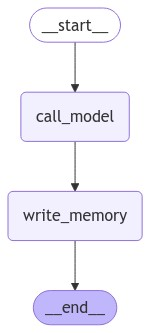

In [ ]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.runnables.config import RunnableConfig

# 聊天机器人系统指令
# 定义机器人的角色和行为规范
MODEL_SYSTEM_MESSAGE = """你是一个有帮助的助手，具有记忆功能，可以提供关于用户的信息。
如果你有这个用户的记忆，请使用它来个性化你的回复。
以下是记忆（可能为空）：{memory}"""

# 从聊天历史和任何现有记忆中创建新记忆的指令
CREATE_MEMORY_INSTRUCTION = """根据用户的聊天历史创建或更新用户档案记忆。
这将保存为长期记忆。如果存在现有记忆，只需更新它。
以下是现有记忆（可能为空）：{memory}"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    从存储中加载记忆并使用它来个性化聊天机器人的回复
    
    参数:
        state: 消息状态，包含当前对话历史
        config: 运行配置，包含用户ID等信息
        store: 存储接口，用于访问长期记忆
    
    返回:
        包含AI回复消息的字典
    """
    
    # 从配置中获取用户ID
    user_id = config["configurable"]["user_id"]

    # 从存储中检索记忆
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    # 为系统提示格式化记忆
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"姓名: {memory_dict.get('user_name', '未知')}\n"
            f"兴趣: {', '.join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None

    # 在系统提示中格式化记忆
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)

    # 使用记忆和聊天历史进行回复
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    反思聊天历史并将记忆保存到存储中
    
    参数:
        state: 消息状态，包含当前对话历史
        config: 运行配置，包含用户ID等信息
        store: 存储接口，用于保存长期记忆
    """
    
    # 从配置中获取用户ID
    user_id = config["configurable"]["user_id"]

    # 从存储中检索现有记忆
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    # 为系统提示格式化记忆
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"姓名: {memory_dict.get('user_name', '未知')}\n"
            f"兴趣: {', '.join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None
        
    # 在指令中格式化现有记忆
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=formatted_memory)

    # 调用模型生成符合模式的结构化输出
    new_memory = model_with_structure.invoke([SystemMessage(content=system_msg)]+state['messages'])

    # 覆盖现有的用户档案记忆
    key = "user_memory"
    store.put(namespace, key, new_memory)

# 定义状态图
# 创建聊天机器人的工作流程
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)  # 调用模型节点
builder.add_node("write_memory", write_memory)  # 写入记忆节点
builder.add_edge(START, "call_model")  # 从开始到调用模型
builder.add_edge("call_model", "write_memory")  # 从调用模型到写入记忆
builder.add_edge("write_memory", END)  # 从写入记忆到结束

# 长期记忆存储（跨线程）
across_thread_memory = InMemoryStore()

# 短期记忆检查点（线程内）
within_thread_memory = MemorySaver()

# 使用检查点和存储编译图
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# 显示图结构
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# 我们提供线程ID用于短期记忆（线程内）
# 我们提供用户ID用于长期记忆（跨线程）
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# 用户输入
# 用户介绍自己的姓名和兴趣
input_messages = [HumanMessage(content="Hi, my name is Lance and I like to bike around San Francisco and eat at bakeries.")]

# 运行图
# 流式处理用户输入并显示AI回复
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance and I like to bike around San Francisco and eat at bakeries.
================================== Ai Message ==================================

Hi Lance! It's great to meet you. Biking around San Francisco sounds like a fantastic way to explore the city, and there are so many amazing bakeries to try. Do you have any favorite bakeries or biking routes in the city?


让我们检查存储中的记忆。

我们可以看到记忆是一个符合我们模式的字典。

### 记忆存储验证
- **数据结构**: 记忆以字典形式存储，包含用户档案信息
- **模式一致性**: 确保存储的数据符合预定义的 UserProfile 模式
- **持久性**: 记忆在会话间保持，支持个性化体验

In [ ]:
# 用于保存记忆的命名空间
user_id = "1"
namespace = ("memory", user_id)
# 从跨线程记忆中获取现有记忆
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.value  # 显示记忆的实际内容

{'user_name': 'Lance', 'interests': ['biking', 'bakeries', 'San Francisco']}

## 什么时候会失败？

[`with_structured_output`](https://python.langchain.com/docs/concepts/structured_outputs/#recommended-usage) 非常有用，但如果我们在处理更复杂的模式时会发生什么？

[这里](https://github.com/hinthornw/trustcall?tab=readme-ov-file#complex-schema) 是一个更复杂模式的示例，我们将在下面测试。

这是一个 [Pydantic](https://docs.pydantic.dev/latest/) 模型，描述了用户在通信和信任跌落方面的偏好。

### 复杂模式的挑战
- **嵌套结构**: 多层嵌套的对象和数组
- **可选字段**: 许多字段可能为空或未定义
- **类型验证**: 严格的类型检查可能导致解析失败
- **模型容量**: 即使是 GPT-4o 这样的高级模型也可能遇到困难

In [ ]:
from typing import List, Optional

class OutputFormat(BaseModel):
    """输出格式模式，包含偏好和句子偏好显示"""
    preference: str  # 用户偏好
    sentence_preference_revealed: str  # 句子偏好显示

class TelegramPreferences(BaseModel):
    """电报偏好模式"""
    preferred_encoding: Optional[List[OutputFormat]] = None  # 首选编码方式
    favorite_telegram_operators: Optional[List[OutputFormat]] = None  # 喜欢的电报操作员
    preferred_telegram_paper: Optional[List[OutputFormat]] = None  # 首选电报纸张

class MorseCode(BaseModel):
    """摩尔斯电码偏好模式"""
    preferred_key_type: Optional[List[OutputFormat]] = None  # 首选键类型
    favorite_morse_abbreviations: Optional[List[OutputFormat]] = None  # 喜欢的摩尔斯缩写

class Semaphore(BaseModel):
    """旗语偏好模式"""
    preferred_flag_color: Optional[List[OutputFormat]] = None  # 首选旗帜颜色
    semaphore_skill_level: Optional[List[OutputFormat]] = None  # 旗语技能水平

class TrustFallPreferences(BaseModel):
    """信任跌落偏好模式"""
    preferred_fall_height: Optional[List[OutputFormat]] = None  # 首选跌落高度
    trust_level: Optional[List[OutputFormat]] = None  # 信任水平
    preferred_catching_technique: Optional[List[OutputFormat]] = None  # 首选接住技巧

class CommunicationPreferences(BaseModel):
    """通信偏好模式"""
    telegram: TelegramPreferences  # 电报偏好
    morse_code: MorseCode  # 摩尔斯电码偏好
    semaphore: Semaphore  # 旗语偏好

class UserPreferences(BaseModel):
    """用户偏好模式"""
    communication_preferences: CommunicationPreferences  # 通信偏好
    trust_fall_preferences: TrustFallPreferences  # 信任跌落偏好

class TelegramAndTrustFallPreferences(BaseModel):
    """电报和信任跌落偏好模式"""
    pertinent_user_preferences: UserPreferences  # 相关用户偏好

现在，让我们尝试使用 `with_structured_output` 方法提取这个模式。

### 测试复杂模式提取
- **目的**: 验证复杂嵌套模式的处理能力
- **挑战**: 多层嵌套结构和可选字段
- **预期结果**: 可能遇到验证错误或解析失败

In [ ]:
from pydantic import ValidationError

# 将复杂模式绑定到模型
model_with_structure = model.with_structured_output(TelegramAndTrustFallPreferences)

# 对话示例
# 这是一个关于电报和信任跌落的虚构对话
conversation = """Operator: How may I assist with your telegram, sir?
Customer: I need to send a message about our trust fall exercise.
Operator: Certainly. Morse code or standard encoding?
Customer: Morse, please. I love using a straight key.
Operator: Excellent. What's your message?
Customer: Tell him I'm ready for a higher fall, and I prefer the diamond formation for catching.
Operator: Done. Shall I use our "Daredevil" paper for this daring message?
Customer: Perfect! Send it by your fastest carrier pigeon.
Operator: It'll be there within the hour, sir."""

# 调用模型进行模式提取
# 使用 try-except 捕获可能的验证错误
try:
    model_with_structure.invoke(f"""Extract the preferences from the following conversation:
    <convo>
    {conversation}
    </convo>""")
except ValidationError as e:
    print(e)

1 validation error for TelegramAndTrustFallPreferences
pertinent_user_preferences.communication_preferences.semaphore
  Input should be a valid dictionary or instance of Semaphore [type=model_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.9/v/model_type


如果我们天真地提取更复杂的模式，即使使用像 `gpt-4o` 这样的高容量模型，也容易失败。

### 复杂模式提取的局限性
- **模型限制**: 即使是最先进的模型也有处理复杂结构的能力限制
- **验证严格性**: Pydantic 的严格类型验证可能导致解析失败
- **上下文理解**: 模型可能无法完全理解所有嵌套关系
- **需要更好的工具**: 这就是为什么我们需要 TrustCall 这样的专门库


## 使用 TrustCall 创建和更新档案模式

正如我们所看到的，处理模式可能很棘手。

复杂的模式可能难以提取。

此外，更新即使是简单的模式也可能带来挑战。

考虑我们上面的聊天机器人。

我们每次选择保存新记忆时都*从头开始*重新生成档案模式。

这是低效的，如果模式包含大量信息需要每次都重新生成，可能会浪费模型令牌。

更糟糕的是，从头重新生成档案时我们可能会丢失信息。

解决这些问题是 [TrustCall](https://github.com/hinthornw/trustcall) 的动机！

这是一个开源库，用于更新 JSON 模式，由 LangChain 团队的 [Will Fu-Hinthorn](https://github.com/hinthornw) 开发。

它正是为了解决在处理记忆时遇到的这些挑战而创建的。

让我们首先展示 TrustCall 在这个 [消息](https://python.langchain.com/docs/concepts/messages/) 列表上的简单提取用法。

### TrustCall 的优势
- **增量更新**: 只更新模式中发生变化的部分
- **效率提升**: 减少模型令牌使用和计算成本
- **信息保持**: 避免在更新过程中丢失现有信息
- **复杂模式支持**: 更好地处理嵌套和复杂的模式结构


In [ ]:
# 对话示例
# 创建一个简单的对话历史用于演示 TrustCall 的提取功能
conversation = [HumanMessage(content="Hi, I'm Lance."), 
                AIMessage(content="Nice to meet you, Lance."), 
                HumanMessage(content="I really like biking around San Francisco.")]

我们使用 `create_extractor`，传入模型以及我们的模式作为 [工具](https://python.langchain.com/docs/concepts/tools/)。

使用 TrustCall，可以以各种方式提供模式。

例如，我们可以传递 JSON 对象 / Python 字典或 Pydantic 模型。

在底层，TrustCall 使用 [工具调用](https://python.langchain.com/docs/concepts/tool_calling/) 从 [消息](https://python.langchain.com/docs/concepts/messages/) 输入列表生成 [结构化输出](https://python.langchain.com/docs/concepts/structured_outputs/)。

要强制 TrustCall 生成 [结构化输出](https://python.langchain.com/docs/concepts/structured_outputs/)，我们可以在 `tool_choice` 参数中包含模式名称。

我们可以使用上面的对话调用提取器。

### TrustCall 工作原理
- **工具调用机制**: 利用 LangChain 的工具调用功能
- **模式灵活性**: 支持多种模式定义方式
- **强制输出**: 通过 tool_choice 确保特定工具被使用
- **消息处理**: 直接处理消息列表，无需额外格式化

In [ ]:
from trustcall import create_extractor

# 用户档案模式定义
class UserProfile(BaseModel):
    """用户档案模式，包含类型化字段"""
    user_name: str = Field(description="用户的首选名称")
    interests: List[str] = Field(description="用户兴趣列表")

# 初始化模型
model = ChatOpenAI(model="gpt-4o", temperature=0)

# 创建提取器
# 使用 TrustCall 创建结构化数据提取器
trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile],  # 将模式作为工具传递
    tool_choice="UserProfile"  # 强制使用 UserProfile 工具
)

# 系统指令
system_msg = "从以下对话中提取用户档案"

# 调用提取器
# 传入系统消息和对话历史
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+conversation})

当我们调用提取器时，我们会得到几个东西：

* `messages`: 包含工具调用的 `AIMessages` 列表。
* `responses`: 符合我们模式的解析后工具调用结果。
* `response_metadata`: 如果更新现有工具调用则适用。它说明哪些响应对应于哪些现有对象。

### 提取结果解析
- **messages**: 包含 AI 模型生成的原始工具调用消息
- **responses**: 解析后的结构化数据，可直接使用
- **response_metadata**: 用于跟踪更新操作的元数据


In [ ]:
# 显示提取器生成的原始消息
# 这些消息包含工具调用的详细信息
for m in result["messages"]: 
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_spGGUsoaUFXU7oOrUNCASzfL)
 Call ID: call_spGGUsoaUFXU7oOrUNCASzfL
  Args:
    user_name: Lance
    interests: ['biking around San Francisco']


In [ ]:
# 获取解析后的结构化数据
# 这是可以直接使用的用户档案对象
schema = result["responses"]
schema

[UserProfile(user_name='Lance', interests=['biking around San Francisco'])]

In [ ]:
# 将 Pydantic 模型转换为字典格式
# 便于查看和进一步处理
schema[0].model_dump()

{'user_name': 'Lance', 'interests': ['biking around San Francisco']}

In [ ]:
# 查看响应元数据
# 包含工具调用的 ID 和相关信息
result["response_metadata"]

[{'id': 'call_spGGUsoaUFXU7oOrUNCASzfL'}]

让我们看看如何使用它来*更新*档案。

对于更新，TrustCall 接受一组消息以及现有模式。

核心思想是它提示模型生成 [JSON Patch](https://jsonpatch.com/) 来仅更新模式的相关部分。

这比天真地覆盖整个模式更不容易出错。

它也更高效，因为模型只需要生成已更改的模式部分。

我们可以将现有模式保存为字典。

我们可以使用 `model_dump()` 将 Pydantic 模型实例序列化为字典。

我们将其与模式名称 `UserProfile` 一起传递给 `"existing"` 参数。

### 增量更新机制
- **JSON Patch**: 只修改发生变化的数据部分
- **错误减少**: 避免完全重写可能导致的错误
- **效率提升**: 减少模型需要处理的数据量
- **信息保持**: 保留未更改的现有信息 

In [ ]:
# 更新对话
# 添加更多关于用户兴趣的信息
updated_conversation = [HumanMessage(content="Hi, I'm Lance."), 
                        AIMessage(content="Nice to meet you, Lance."), 
                        HumanMessage(content="I really like biking around San Francisco."),
                        AIMessage(content="San Francisco is a great city! Where do you go after biking?"),
                        HumanMessage(content="I really like to go to a bakery after biking."),]

# 更新指令
# 指示模型更新现有记忆而不是创建新记忆
system_msg = f"""更新记忆（JSON 文档）以整合以下对话中的新信息"""

# 使用更新后的指令和现有档案调用提取器
# 传入现有档案数据以进行增量更新
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+updated_conversation}, 
                                    {"existing": {"UserProfile": schema[0].model_dump()}})  

In [ ]:
# 显示更新后的工具调用消息
# 查看模型如何更新现有档案
for m in result["messages"]: 
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_WeZl0ACfQStxblim0ps8LNKT)
 Call ID: call_WeZl0ACfQStxblim0ps8LNKT
  Args:
    user_name: Lance
    interests: ['biking', 'visiting bakeries']


In [ ]:
# 查看更新操作的元数据
# 显示哪些响应对应哪些现有对象
result["response_metadata"]

[{'id': 'call_WeZl0ACfQStxblim0ps8LNKT'}]

In [ ]:
# 获取更新后的档案
# 这是包含新信息的完整用户档案
updated_schema = result["responses"][0]
updated_schema.model_dump()  # 转换为字典格式查看

{'user_name': 'Lance', 'interests': ['biking', 'visiting bakeries']}

LangSmith 追踪：

https://smith.langchain.com/public/229eae22-1edb-44c6-93e6-489124a43968/r

现在，让我们也在之前看到的 [挑战性模式](https://github.com/hinthornw/trustcall?tab=readme-ov-file#complex-schema) 上测试 TrustCall。

### 复杂模式测试
- **目的**: 验证 TrustCall 处理复杂嵌套模式的能力
- **对比**: 与之前使用 `with_structured_output` 的失败案例进行对比
- **预期**: TrustCall 应该能够成功处理复杂的模式结构

In [ ]:
# 创建复杂模式的提取器
# 使用之前定义的复杂嵌套模式
bound = create_extractor(
    model,
    tools=[TelegramAndTrustFallPreferences],
    tool_choice="TelegramAndTrustFallPreferences",
)

# 对话示例
# 包含电报和信任跌落偏好的虚构对话
conversation = """Operator: How may I assist with your telegram, sir?
Customer: I need to send a message about our trust fall exercise.
Operator: Certainly. Morse code or standard encoding?
Customer: Morse, please. I love using a straight key.
Operator: Excellent. What's your message?
Customer: Tell him I'm ready for a higher fall, and I prefer the diamond formation for catching.
Operator: Done. Shall I use our "Daredevil" paper for this daring message?
Customer: Perfect! Send it by your fastest carrier pigeon.
Operator: It'll be there within the hour, sir."""

# 调用提取器处理复杂模式
result = bound.invoke(
    f"""从以下对话中提取偏好：
<convo>
{conversation}
</convo>"""
)

# 提取偏好数据
# 显示成功解析的复杂模式结果
result["responses"][0]

TelegramAndTrustFallPreferences(pertinent_user_preferences=UserPreferences(communication_preferences=CommunicationPreferences(telegram=TelegramPreferences(preferred_encoding=[OutputFormat(preference='standard encoding', sentence_preference_revealed='standard encoding')], favorite_telegram_operators=None, preferred_telegram_paper=[OutputFormat(preference='Daredevil', sentence_preference_revealed='Daredevil')]), morse_code=MorseCode(preferred_key_type=[OutputFormat(preference='straight key', sentence_preference_revealed='straight key')], favorite_morse_abbreviations=None), semaphore=Semaphore(preferred_flag_color=None, semaphore_skill_level=None)), trust_fall_preferences=TrustFallPreferences(preferred_fall_height=[OutputFormat(preference='higher', sentence_preference_revealed='higher')], trust_level=None, preferred_catching_technique=[OutputFormat(preference='diamond formation', sentence_preference_revealed='diamond formation')])))

追踪：

https://smith.langchain.com/public/5cd23009-3e05-4b00-99f0-c66ee3edd06e/r

更多示例，您可以查看概述视频 [这里](https://www.youtube.com/watch?v=-H4s0jQi-QY)。

### TrustCall 成功案例
- **复杂模式处理**: 成功处理了多层嵌套的复杂模式
- **工具调用优势**: 利用工具调用机制提高了成功率
- **模式灵活性**: 支持各种复杂的数据结构

## 基于档案模式更新的聊天机器人

现在，让我们将 TrustCall 集成到我们的聊天机器人中，以创建*和更新*记忆档案。

### 集成 TrustCall 的优势
- **智能更新**: 只更新发生变化的部分，保持现有信息
- **效率提升**: 减少模型令牌使用和计算成本
- **错误减少**: 避免完全重写可能导致的错误
- **复杂模式支持**: 更好地处理嵌套和复杂的用户档案结构

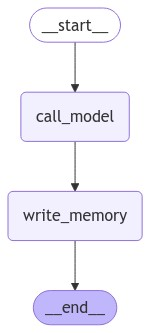

In [ ]:
from IPython.display import Image, display

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

# 初始化模型
model = ChatOpenAI(model="gpt-4o", temperature=0)

# 用户档案模式定义
class UserProfile(BaseModel):
    """用户档案模式"""
    user_name: str = Field(description="用户的首选名称")
    user_location: str = Field(description="用户的位置")
    interests: list = Field(description="用户兴趣列表")

# 创建 TrustCall 提取器
# 用于智能更新用户档案
trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile],
    tool_choice="UserProfile",  # 强制使用 UserProfile 工具
)

# 聊天机器人系统指令
MODEL_SYSTEM_MESSAGE = """你是一个有帮助的助手，具有记忆功能，可以提供关于用户的信息。
如果你有这个用户的记忆，请使用它来个性化你的回复。
以下是记忆（可能为空）：{memory}"""

# TrustCall 提取指令
TRUSTCALL_INSTRUCTION = """创建或更新记忆（JSON 文档）以整合以下对话中的信息："""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    从存储中加载记忆并使用它来个性化聊天机器人的回复
    
    参数:
        state: 消息状态，包含当前对话历史
        config: 运行配置，包含用户ID等信息
        store: 存储接口，用于访问长期记忆
    
    返回:
        包含AI回复消息的字典
    """
    
    # 从配置中获取用户ID
    user_id = config["configurable"]["user_id"]

    # 从存储中检索记忆
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    # 为系统提示格式化记忆
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"姓名: {memory_dict.get('user_name', '未知')}\n"
            f"位置: {memory_dict.get('user_location', '未知')}\n"
            f"兴趣: {', '.join(memory_dict.get('interests', []))}"      
        )
    else:
        formatted_memory = None

    # 在系统提示中格式化记忆
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)

    # 使用记忆和聊天历史进行回复
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    使用 TrustCall 智能更新记忆档案
    
    参数:
        state: 消息状态，包含当前对话历史
        config: 运行配置，包含用户ID等信息
        store: 存储接口，用于保存长期记忆
    """
    
    # 从配置中获取用户ID
    user_id = config["configurable"]["user_id"]

    # 从存储中检索现有记忆
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
        
    # 获取现有档案并转换为 JSON 文档格式
    # 如果存在记忆，则用于增量更新；否则创建新档案
    existing_profile = {"UserProfile": existing_memory.value} if existing_memory else None
    
    # 调用 TrustCall 提取器进行智能更新
    result = trustcall_extractor.invoke({"messages": [SystemMessage(content=TRUSTCALL_INSTRUCTION)]+state["messages"], "existing": existing_profile})
    
    # 获取更新后的档案作为 JSON 对象
    updated_profile = result["responses"][0].model_dump()

    # 保存更新后的档案
    key = "user_memory"
    store.put(namespace, key, updated_profile)

# 定义状态图
# 创建集成 TrustCall 的聊天机器人工作流程
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)  # 调用模型节点
builder.add_node("write_memory", write_memory)  # 智能写入记忆节点
builder.add_edge(START, "call_model")  # 从开始到调用模型
builder.add_edge("call_model", "write_memory")  # 从调用模型到写入记忆
builder.add_edge("write_memory", END)  # 从写入记忆到结束

# 长期记忆存储（跨线程）
across_thread_memory = InMemoryStore()

# 短期记忆检查点（线程内）
within_thread_memory = MemorySaver()

# 使用检查点和存储编译图
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# 显示图结构
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# 我们提供线程ID用于短期记忆（线程内）
# 我们提供用户ID用于长期记忆（跨线程）
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# 用户输入
# 用户介绍自己的姓名
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# 运行图
# 流式处理用户输入并显示AI回复
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hello, Lance! It's nice to meet you. How can I assist you today?


In [ ]:
# 用户输入
# 用户分享自己的兴趣和位置信息
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# 运行图
# 流式处理用户输入并显示AI回复
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That sounds like a great way to explore the city! San Francisco has some beautiful routes and views. Do you have any favorite trails or spots you like to visit while biking?


In [ ]:
# 用于保存记忆的命名空间
user_id = "1"
namespace = ("memory", user_id)
# 从跨线程记忆中获取现有记忆
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.dict()  # 显示完整的记忆对象信息

{'value': {'user_name': 'Lance',
  'user_location': 'San Francisco',
  'interests': ['biking']},
 'key': 'user_memory',
 'namespace': ['memory', '1'],
 'created_at': '2024-11-04T23:51:17.662428+00:00',
 'updated_at': '2024-11-04T23:51:41.697652+00:00'}

In [ ]:
# 以 JSON 对象形式保存的用户档案
# 显示实际存储的用户档案数据
existing_memory.value

{'user_name': 'Lance',
 'user_location': 'San Francisco',
 'interests': ['biking']}

In [ ]:
# 用户输入
# 用户添加新的兴趣信息
input_messages = [HumanMessage(content="I also enjoy going to bakeries")]

# 运行图
# 流式处理用户输入并显示AI回复
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I also enjoy going to bakeries
================================== Ai Message ==================================

Biking and visiting bakeries sounds like a delightful combination! San Francisco has some fantastic bakeries. Do you have any favorites, or are you looking for new recommendations to try out?


在新线程中继续对话。

### 跨线程记忆测试
- **目的**: 验证长期记忆在不同会话间的持久性
- **测试场景**: 使用新的线程ID但相同的用户ID
- **预期结果**: 机器人应该记住之前会话中的用户信息

In [ ]:
# 我们提供线程ID用于短期记忆（线程内）
# 我们提供用户ID用于长期记忆（跨线程）
# 注意：使用新的线程ID "2"，但相同的用户ID "1"
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# 用户输入
# 用户询问面包店推荐，测试长期记忆是否有效
input_messages = [HumanMessage(content="What bakeries do you recommend for me?")]

# 运行图
# 流式处理用户输入并显示AI回复
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

What bakeries do you recommend for me?
================================== Ai Message ==================================

Since you're in San Francisco and enjoy going to bakeries, here are a few recommendations you might like:

1. **Tartine Bakery** - Known for its delicious bread and pastries, it's a must-visit for any bakery enthusiast.
2. **B. Patisserie** - Offers a delightful selection of French pastries, including their famous kouign-amann.
3. **Arsicault Bakery** - Renowned for its croissants, which have been praised as some of the best in the country.
4. **Craftsman and Wolves** - Known for their inventive pastries and the "Rebel Within," a savory muffin with a soft-cooked egg inside.
5. **Mr. Holmes Bakehouse** - Famous for their cruffins and other creative pastries.

These spots should offer a great variety of treats for you to enjoy. Happy bakery hopping!


追踪：

https://smith.langchain.com/public/f45bdaf0-6963-4c19-8ec9-f4b7fe0f68ad/r

## LangGraph Studio

![Screenshot 2024-10-30 at 11.26.31 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6732d0437060f1754ea79908_Screenshot%202024-11-11%20at%207.48.53%E2%80%AFPM.png)

### 项目总结

通过这个教程，我们学习了：

1. **结构化记忆**: 使用 TypedDict 和 Pydantic 定义用户档案模式
2. **LangGraph 存储**: 使用 InMemoryStore 保存和检索长期记忆
3. **结构化输出**: 使用 `with_structured_output` 确保模型输出符合模式
4. **TrustCall 集成**: 使用 TrustCall 进行智能的增量更新
5. **跨线程记忆**: 实现不同会话间的记忆持久化

### 技术要点
- **模式设计**: 合理设计数据结构以支持用户档案管理
- **记忆管理**: 区分短期和长期记忆的不同用途
- **智能更新**: 使用 TrustCall 避免完全重写，提高效率
- **个性化体验**: 基于用户档案提供个性化的聊天体验